In [1]:

# --- Setup ---
# Run this notebook from a folder that already contains the data/ directory
# (education_services.csv and the external/ subfolder with the shapefile and
# GeoJSON basemap). If a package is missing, install it before running:
#   pip install geopandas scipy pyarrow pandas numpy matplotlib
import os, sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !pip install -q geopandas scipy pyarrow

print("Working directory:", os.getcwd())
print("Data file present:", os.path.exists("data/education_services.csv"))
print("SOS shapefile present:", os.path.exists("data/external/sos_2021/SOS_2021_AUST_GDA2020.shp"))

if not os.path.exists("data/education_services.csv"):
    print("\nData not found. Place the data/ folder (education_services.csv "
          "and the external/ subfolder) in the same directory as this "
          "notebook, then re-run this cell.")


Working directory: /home/user/Mart
Data file present: True
SOS shapefile present: True


In [2]:

import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
from scipy.spatial import cKDTree
import geopandas as gpd

RAW_PATH = Path("data/education_services.csv")
AU_STATES_GEOJSON = Path("data/external/au_states.geojson")
SOS_SHAPEFILE = Path("data/external/sos_2021/SOS_2021_AUST_GDA2020.shp")
FIG_DIR = Path("outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
summary = {}  # every chart appends its own headline stats here, right after drawing


In [3]:

raw = pd.read_csv(RAW_PATH, low_memory=False)
print(raw.shape)
raw[["ServiceName", "State", "Suburb", "Postcode", "geometry"]].head()


(17663, 103)


,ServiceName,State,Suburb,Postcode,geometry
0,Community Kids Waterford Early Education Centre,QLD,WATERFORD WEST,4133.0,"c(153.133902919075, -27.690513207433)"
1,KIDVENTURE EARLY LEARNING EAGLEBY,QLD,EAGLEBY,4207.0,"c(153.211787647201, -27.707467576353)"
2,Community Kids - Broadbeach Waters,QLD,BROADBEACH WATERS,4217.0,"c(153.410339594544, -28.024767831911)"
3,Little Scholars School of Early Learning Burle...,QLD,BURLEIGH WATERS,4220.0,"c(153.431380518447, -28.082157591396)"
4,Small World Child Care Centre,QLD,CARRARA,4211.0,"c(153.351670127991, -28.005580607804)"


In [4]:

dup_geom = raw["geometry"].value_counts()
dup_geom = dup_geom[dup_geom > 3]
print(dup_geom)


geometry
c(97.48747, 23.14958)                    10
c(145.741929531156, -17.007042588225)     4
c(145.363114748785, -38.083890922407)     4
c(151.128664850783, -33.878545511457)     4
c(149.1025717692, -35.307236507212)       4
Name: count, dtype: int64


In [5]:

bad = raw[raw["geometry"] == "c(97.48747, 23.14958)"]
bad[["ServiceName", "State", "Suburb", "Postcode", "FullAddress"]]


,ServiceName,State,Suburb,Postcode,FullAddress
1590,Ace Academy Morayfield,NaN,NaN,NaN,"NA, NA, NA, NA"
5385,Callala Bay Preschool Education Centre,NaN,NaN,NaN,"NA, NA, NA, NA"
6370,Koolyangarra Aboriginal Preschool Corporation,NaN,NaN,NaN,"NA, NA, NA, NA"
6731,Merriwa Pre-School And Activity Centre Incorpo...,NaN,NaN,NaN,"NA, NA, NA, NA"
7266,Guardian Childcare & Education Margaret Street,NaN,NaN,NaN,"NA, NA, NA, NA"
12140,Clarence City Council - Lindisfarne North OSHC,NaN,NaN,NaN,"NA, NA, NA, NA"
12909,Blossoms Childcare & Early Learning Centre,NaN,NaN,NaN,"NA, NA, NA, NA"
12977,Genius Childcare Lane Cove,NaN,NaN,NaN,"NA, NA, NA, NA"
16713,Clarke Creek State School Kindergarten,NaN,NaN,NaN,"NA, NA, NA, NA"
16834,Grow Early Education Maroochydore,NaN,NaN,NaN,"NA, NA, NA, NA"


In [6]:

NOT_YET_ASSESSED = "Provisional – Not Yet Assessed"
RATING_ORDER_SUBSTANTIVE = [
    "Significant Improvement Required", "Working Towards NQS", "Meeting NQS", "Exceeding NQS", "Excellent",
]
RATING_ORDER = [NOT_YET_ASSESSED] + RATING_ORDER_SUBSTANTIVE

QUALITY_AREA_LABELS = {
    "QualityArea1Rating": "QA1 Educational program",
    "QualityArea2Rating": "QA2 Children's health & safety",
    "QualityArea3Rating": "QA3 Physical environment",
    "QualityArea4Rating": "QA4 Staffing arrangements",
    "QualityArea5Rating": "QA5 Relationships with children",
    "QualityArea6Rating": "QA6 Collaborative partnerships",
    "QualityArea7Rating": "QA7 Governance & leadership",
}
RATING_COLS = ["OverallRating"] + list(QUALITY_AREA_LABELS.keys())

DETAILED_SERVICE_TYPE_COLS = [
    "Long Day Care", "Preschool/Kindergarten - Part of a School", "Preschool/Kindergarten - Stand alone",
    "Outside school Hours Care - After School", "Outside school Hours Care - Before School",
    "Outside school Hours Care - Vacation Care", "Other",
]

AU_LON_RANGE = (105.0, 170.0)
AU_LAT_RANGE = (-45.0, -8.0)
_GEOM_RE = re.compile(r"c\(\s*([-\d.]+)\s*,\s*([-\d.]+)\s*\)")


def parse_geometry(series):
    parsed = series.astype(str).str.extract(_GEOM_RE)
    lon = pd.to_numeric(parsed[0], errors="coerce")
    lat = pd.to_numeric(parsed[1], errors="coerce")
    return lon, lat


def clean(df):
    df = df.copy()
    n_start = len(df)

    bad_geocode = df["geometry"].eq("c(97.48747, 23.14958)")
    df = df.loc[~bad_geocode].copy()

    df["lon"], df["lat"] = parse_geometry(df["geometry"])
    out_of_bounds = (
        df["lon"].lt(AU_LON_RANGE[0]) | df["lon"].gt(AU_LON_RANGE[1]) |
        df["lat"].lt(AU_LAT_RANGE[0]) | df["lat"].gt(AU_LAT_RANGE[1])
    )
    df["geocode_suspect"] = out_of_bounds.fillna(True)

    df["ServiceApprovalGrantedDate"] = pd.to_datetime(df["ServiceApprovalGrantedDate"], dayfirst=True, errors="coerce")
    df["ApprovalYear"] = df["ServiceApprovalGrantedDate"].dt.year

    for col in RATING_COLS:
        df[col] = pd.Categorical(df[col], categories=RATING_ORDER, ordered=True)
    df["IsRated"] = df["OverallRating"].notna()

    for col in DETAILED_SERVICE_TYPE_COLS:
        df[col] = df[col].map({"Yes": True, "No": False})

    df["NumberOfApprovedPlaces"] = pd.to_numeric(df["NumberOfApprovedPlaces"], errors="coerce")

    df["train_dist_outlier"] = df["DistanceToTrainStation_km"] > 100
    df["bus_dist_outlier"] = df["DistanceToBusStation_km"] > 100

    df["State"] = df["State"].str.strip()
    df["Postcode"] = pd.to_numeric(df["Postcode"], errors="coerce").astype("Int64")

    n_end = len(df)
    print(f"{n_start} -> {n_end} rows ({n_start - n_end} dropped: unusable geocode/address); "
          f"{df['geocode_suspect'].sum()} remaining rows flagged geocode_suspect")
    return df


def rated_only(series):
    return series[series.astype(str) != NOT_YET_ASSESSED]


df = clean(raw)
summary["n_services_total"] = int(len(df))
df[["OverallRating"]].value_counts(dropna=False)


17663 -> 17653 rows (10 dropped: unusable geocode/address); 0 remaining rows flagged geocode_suspect


OverallRating                   
Meeting NQS                         11351
Exceeding NQS                        3464
Working Towards NQS                  1472
nan                                  1326
Excellent                              27
Significant Improvement Required       13
Provisional – Not Yet Assessed          0
Name: count, dtype: int64

In [7]:

def primary_service_type(df):
    conditions = [
        df["ServiceType"].eq("Family Day Care"),
        df["Long Day Care"].eq(True),
        df["Preschool/Kindergarten - Stand alone"].eq(True),
        df["Preschool/Kindergarten - Part of a School"].eq(True),
        df[[
            "Outside school Hours Care - After School",
            "Outside school Hours Care - Before School",
            "Outside school Hours Care - Vacation Care",
        ]].any(axis=1),
    ]
    choices = ["Family Day Care", "Long Day Care", "Preschool (standalone)", "Preschool (school-based)", "Outside School Hours Care"]
    return pd.Series(np.select(conditions, choices, default="Other"), index=df.index)

df["PrimaryServiceType"] = primary_service_type(df)
df["PrimaryServiceType"].value_counts()


PrimaryServiceType
Long Day Care                9297
Outside School Hours Care    4935
Preschool (standalone)       2295
Preschool (school-based)      706
Family Day Care               417
Other                           3
Name: count, dtype: int64

In [8]:

INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"
CAT = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
RATING_COLORS = dict(zip(RATING_ORDER_SUBSTANTIVE, SEQ_BLUE[2:]))
RATING_COLORS[NOT_YET_ASSESSED] = "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY, "text.color": INK_PRIMARY,
    "xtick.color": INK_SECONDARY, "ytick.color": INK_SECONDARY,
    "axes.grid": False, "font.family": "sans-serif", "font.size": 11,
})


def stacked_bar(ax, props, order, colors, value_fmt="{:.0%}"):
    left = np.zeros(len(props))
    y = np.arange(len(props))
    for cat in order:
        vals = props[cat].to_numpy()
        ax.barh(y, vals, left=left, height=0.62, color=colors[cat], edgecolor=SURFACE, linewidth=1.2, label=cat)
        for i, v in enumerate(vals):
            if v >= 0.08:
                ax.text(left[i] + v / 2, y[i], value_fmt.format(v), ha="center", va="center",
                        fontsize=8.5, color="white" if colors[cat] != RATING_COLORS[NOT_YET_ASSESSED] else INK_PRIMARY)
        left += vals
    ax.set_yticks(y); ax.set_yticklabels(props.index)
    ax.set_xlim(0, 1); ax.set_xticks([0, .25, .5, .75, 1.0])
    ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
    ax.invert_yaxis()
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.tick_params(left=False)


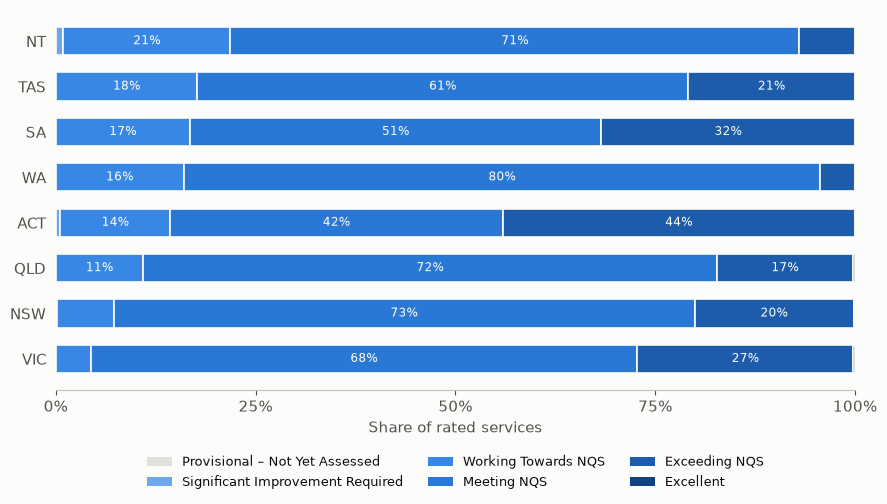

Worst: NT (21.9% non-compliant)   Best: VIC (4.4% non-compliant)


In [9]:

rated = df[df["State"].notna()].copy()
rated["OverallRating"] = rated["OverallRating"].astype(str)
props = (
    rated.groupby("State")["OverallRating"].value_counts(normalize=True)
    .unstack(fill_value=0).reindex(columns=RATING_ORDER, fill_value=0)
)
# Sort by non-compliance (Working Towards + Significant Improvement
# Required), worst first - consistent with the non-compliance framing
# used everywhere else in this stream.
props["_score"] = props["Working Towards NQS"] + props["Significant Improvement Required"]
props = props.sort_values("_score", ascending=False).drop(columns="_score")

fig, ax = plt.subplots(figsize=(9, 5.2))
stacked_bar(ax, props, RATING_ORDER, RATING_COLORS)
ax.set_xlabel("Share of rated services")
handles = [Patch(facecolor=RATING_COLORS[c], label=c) for c in RATING_ORDER]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3, frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_rating_by_state.png", dpi=200)
plt.show()

worst_state, best_state = props.index[0], props.index[-1]
summary["best_state"] = best_state
summary["worst_state"] = worst_state
summary["best_state_noncompliance_pct"] = round(float(props.loc[best_state, "Working Towards NQS"] + props.loc[best_state, "Significant Improvement Required"]) * 100, 1)
summary["worst_state_noncompliance_pct"] = round(float(props.loc[worst_state, "Working Towards NQS"] + props.loc[worst_state, "Significant Improvement Required"]) * 100, 1)
print(f"Worst: {worst_state} ({summary['worst_state_noncompliance_pct']}% non-compliant)   Best: {best_state} ({summary['best_state_noncompliance_pct']}% non-compliant)")


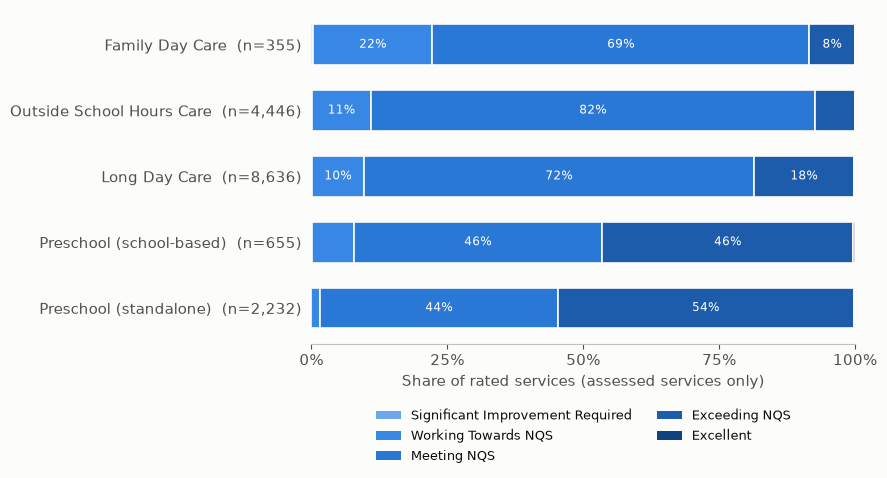

In [10]:

d2 = df[df["PrimaryServiceType"] != "Other"].copy()
d2 = d2[d2["OverallRating"].notna()]
d2["OverallRating"] = d2["OverallRating"].astype(str)
d2 = d2[d2["OverallRating"] != NOT_YET_ASSESSED]

props2 = (
    d2.groupby("PrimaryServiceType")["OverallRating"].value_counts(normalize=True)
    .unstack(fill_value=0).reindex(columns=RATING_ORDER_SUBSTANTIVE, fill_value=0)
)
counts2 = d2["PrimaryServiceType"].value_counts()
# Ranked by non-compliance, worst first - consistent with Chart 1 and
# Chart 3's framing (who's actually failing the legal minimum, not who's
# excelling).
props2["_score"] = props2["Working Towards NQS"] + props2["Significant Improvement Required"]
props2 = props2.sort_values("_score", ascending=False).drop(columns="_score")
props2.index = [f"{i}  (n={counts2[i]:,})" for i in props2.index]

fig, ax = plt.subplots(figsize=(9, 5.0))
stacked_bar(ax, props2, RATING_ORDER_SUBSTANTIVE, RATING_COLORS)
ax.set_xlabel("Share of rated services (assessed services only)")
handles = [Patch(facecolor=RATING_COLORS[c], label=c) for c in RATING_ORDER_SUBSTANTIVE]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_rating_by_service_type.png", dpi=200)
plt.show()

summary["service_type_counts"] = counts2.to_dict()


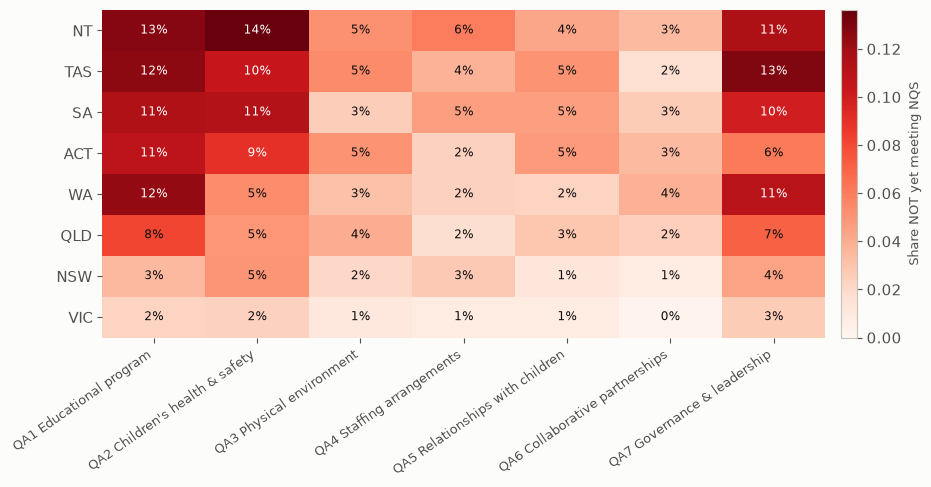

Weakest (highest non-compliance): QA1 Educational program
Strongest (lowest non-compliance): QA6 Collaborative partnerships

Mean non-compliance by state, worst first:
NT     8.1
TAS    7.4
SA     6.7
ACT    5.9
WA     5.8
QLD    4.5
NSW    2.8
VIC    1.4
dtype: float64


In [11]:

d3 = df[df["State"].notna()].copy()
qa_cols = list(QUALITY_AREA_LABELS.keys())
rows = []
for state, g in d3.groupby("State"):
    row = {}
    for col in qa_cols:
        s = g[col].astype(str)
        s = s[(s != "nan") & (s != NOT_YET_ASSESSED)]
        # Non-compliance: rated below the NQS standard - the areas actively
        # failing to meet the National Law, not just short of "Exceeding".
        row[QUALITY_AREA_LABELS[col]] = s.isin(["Working Towards NQS", "Significant Improvement Required"]).mean() if len(s) else np.nan
    rows.append(pd.Series(row, name=state))
heat = pd.DataFrame(rows)
heat = heat.loc[heat.mean(axis=1).sort_values(ascending=False).index]  # worst (highest non-compliance) first

fig, ax = plt.subplots(figsize=(9.5, 5))
im = ax.imshow(heat.values, cmap="Reds", vmin=0, vmax=heat.values.max(), aspect="auto")
ax.set_xticks(range(len(heat.columns))); ax.set_xticklabels(heat.columns, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(heat.index))); ax.set_yticklabels(heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=8.5,
                color="white" if v > heat.values.max() * 0.6 else INK_PRIMARY)
for spine in ax.spines.values():
    spine.set_visible(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Share NOT yet meeting NQS", color=INK_SECONDARY, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_quality_area_heatmap.png", dpi=200)
plt.show()

summary["weakest_quality_area_nationally"] = heat.mean(axis=0).idxmax()  # highest non-compliance
summary["strongest_quality_area_nationally"] = heat.mean(axis=0).idxmin()  # lowest non-compliance
print("Weakest (highest non-compliance):", summary["weakest_quality_area_nationally"])
print("Strongest (lowest non-compliance):", summary["strongest_quality_area_nationally"])
print()
print("Mean non-compliance by state, worst first:")
print((heat.mean(axis=1) * 100).round(1))


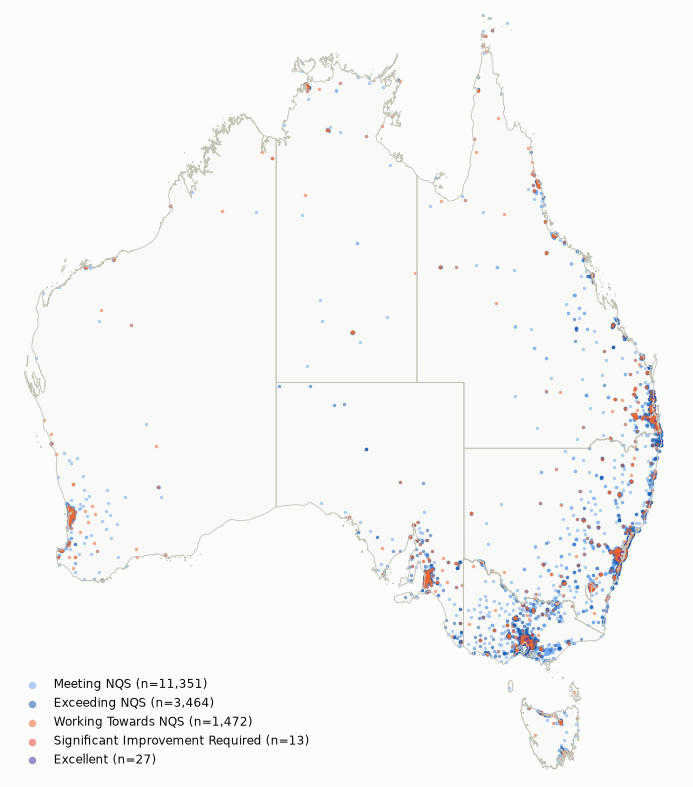

In [12]:

d4 = df[df["lon"].notna() & df["lat"].notna() & ~df["geocode_suspect"]].copy()
d4["OverallRating"] = d4["OverallRating"].astype(str)
tier_colors = {
    "Significant Improvement Required": CAT["red"], "Working Towards NQS": CAT["orange"],
    "Meeting NQS": SEQ_BLUE[2], "Exceeding NQS": SEQ_BLUE[5], "Excellent": CAT["violet"],
}
states = gpd.read_file(AU_STATES_GEOJSON)

fig, ax = plt.subplots(figsize=(9, 8))
states.boundary.plot(ax=ax, color=BASELINE, linewidth=0.6)
states.plot(ax=ax, color="#f9f9f7", edgecolor="none", zorder=0)
for tier in ["Meeting NQS", "Exceeding NQS", "Working Towards NQS", "Significant Improvement Required", "Excellent"]:
    sub = d4[d4["OverallRating"] == tier]
    if len(sub) == 0:
        continue
    ax.scatter(sub["lon"], sub["lat"], s=6, alpha=0.55, linewidths=0, color=tier_colors[tier], label=f"{tier} (n={len(sub):,})")
ax.set_xlim(112, 155); ax.set_ylim(-44, -9); ax.set_aspect(1.4)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc="lower left", frameon=False, fontsize=8.5, markerscale=2.2)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_spatial_ratings_map.png", dpi=200)
plt.show()

summary["n_mapped"] = int(len(d4))
summary["n_excluded_suspect_geocode"] = int(df["geocode_suspect"].sum())


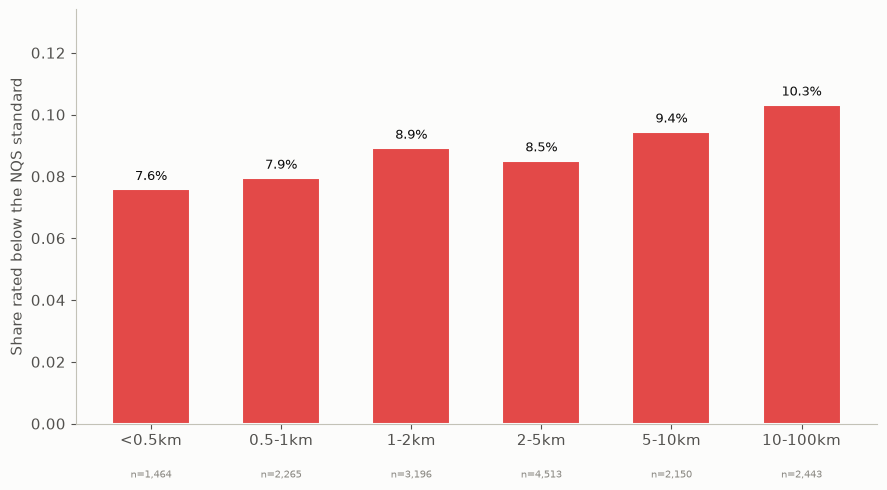

Spearman rho = 0.0259, p = 0.00105, n = 16,031


In [13]:

idx5 = rated_only(df["OverallRating"].dropna()).index
sub5 = df.loc[idx5].copy()
sub5["OverallRating"] = sub5["OverallRating"].astype(str)
# "Negative impact" = falling BELOW the NQS standard (Working Towards NQS or
# Significant Improvement Required) - a direct "at risk" measure, rather than
# the share exceeding it.
sub5["BelowStandard"] = sub5["OverallRating"].isin(["Working Towards NQS", "Significant Improvement Required"]).astype(int)
sub5_clean = sub5[~sub5["train_dist_outlier"]].copy()
n_excluded5 = int(sub5["train_dist_outlier"].sum())

bins5 = [0, 0.5, 1, 2, 5, 10, 100]
labels5 = ["<0.5km", "0.5-1km", "1-2km", "2-5km", "5-10km", "10-100km"]
sub5_clean["dist_bin"] = pd.cut(sub5_clean["DistanceToTrainStation_km"], bins=bins5, labels=labels5)
props5 = sub5_clean.groupby("dist_bin", observed=True)["BelowStandard"].mean()
counts5 = sub5_clean["dist_bin"].value_counts().reindex(labels5)

rho5, pval5 = stats.spearmanr(sub5_clean["DistanceToTrainStation_km"], sub5_clean["BelowStandard"])

ymax5 = max(props5.max() * 1.3, 0.05)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels5, props5.reindex(labels5).values, color=CAT["red"], width=0.6, edgecolor=SURFACE, linewidth=1.5)
for bar, lbl in zip(bars, labels5):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003, f"{bar.get_height():.1%}", ha="center", fontsize=9, color=INK_PRIMARY)
    ax.text(bar.get_x() + bar.get_width() / 2, -0.13 * ymax5, f"n={counts5[lbl]:,}", ha="center", fontsize=7.5, color=INK_MUTED)
ax.set_ylim(0, ymax5)
ax.set_ylabel("Share rated below the NQS standard")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(BASELINE); ax.spines["bottom"].set_color(BASELINE)
fig.tight_layout()
fig.savefig(FIG_DIR / "05_transport_vs_quality.png", dpi=200)
plt.show()

summary["transport_belowstandard_spearman_rho"] = round(float(rho5), 4)
summary["transport_belowstandard_spearman_p"] = float(pval5)
summary["belowstandard_pct_closest_bin"] = round(float(props5.iloc[0]) * 100, 1)
summary["belowstandard_pct_farthest_bin"] = round(float(props5.iloc[-1]) * 100, 1)
summary["n_excluded_remote_outliers"] = n_excluded5
print(f"Spearman rho = {rho5:.4f}, p = {pval5:.3g}, n = {len(sub5_clean):,}")


In [14]:

URBAN_CATEGORIES = {"Major Urban", "Other Urban"}
RURAL_CATEGORIES = {"Bounded Locality", "Rural Balance"}
SOS_ORDER = ["Major Urban", "Other Urban", "Bounded Locality", "Rural Balance"]
MIN_CELL_N = 15  # cells below this are masked - too few services for a reliable rate

# A service counts as "well-connected" if it's within a short drive of
# either mode - not walking distance, which the data doesn't support as a
# national baseline (median distance to a bus stop alone is 9.3km). 5km to
# a train station and 10km to a bus stop are both roughly a 10-15 minute
# drive - a reasonable "not effectively cut off" bar, set so the majority
# of the country clears it and the minority that doesn't stands out as a
# real gap rather than an artefact of an unrealistically strict cutoff.
TRAIN_CONNECTED_KM = 5.0
BUS_CONNECTED_KM = 10.0


def classify_urban_rural(df):
    sos = gpd.read_file(SOS_SHAPEFILE)
    sos = sos[sos.geometry.notna()].copy()

    pts = gpd.GeoDataFrame(
        df[["lon", "lat"]], geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs="EPSG:4326", index=df.index,
    ).to_crs(sos.crs)

    cols = ["SOS_NAME21", "STE_NAME21", "geometry"]
    joined = gpd.sjoin(pts, sos[cols], how="left", predicate="within")
    joined = joined[~joined.index.duplicated(keep="first")]

    unmatched = joined["SOS_NAME21"].isna()
    if unmatched.any():
        albers = "EPSG:3577"
        nearest = gpd.sjoin_nearest(pts.loc[unmatched].to_crs(albers), sos[cols].to_crs(albers), how="left")
        nearest = nearest[~nearest.index.duplicated(keep="first")]
        joined.loc[unmatched, "SOS_NAME21"] = nearest["SOS_NAME21"]
        joined.loc[unmatched, "STE_NAME21"] = nearest["STE_NAME21"]

    out = df.copy()
    out["SOS_Category"] = joined["SOS_NAME21"].reindex(out.index)
    out["UrbanRural"] = out["SOS_Category"].map(
        lambda c: "Urban" if c in URBAN_CATEGORIES else ("Rural" if c in RURAL_CATEGORIES else pd.NA)
    )
    return out, sos


df, sos_boundaries = classify_urban_rural(df)
sos_area_by_cat = sos_boundaries.groupby("SOS_NAME21")["AREASQKM21"].sum()
summary["urban_rural_counts"] = df["UrbanRural"].value_counts(dropna=False).to_dict()
summary["sos_category_counts"] = df["SOS_Category"].value_counts(dropna=False).to_dict()
df["SOS_Category"].value_counts(dropna=False)


SOS_Category
Major Urban         12850
Other Urban          3578
Bounded Locality      616
Rural Balance         609
Name: count, dtype: int64

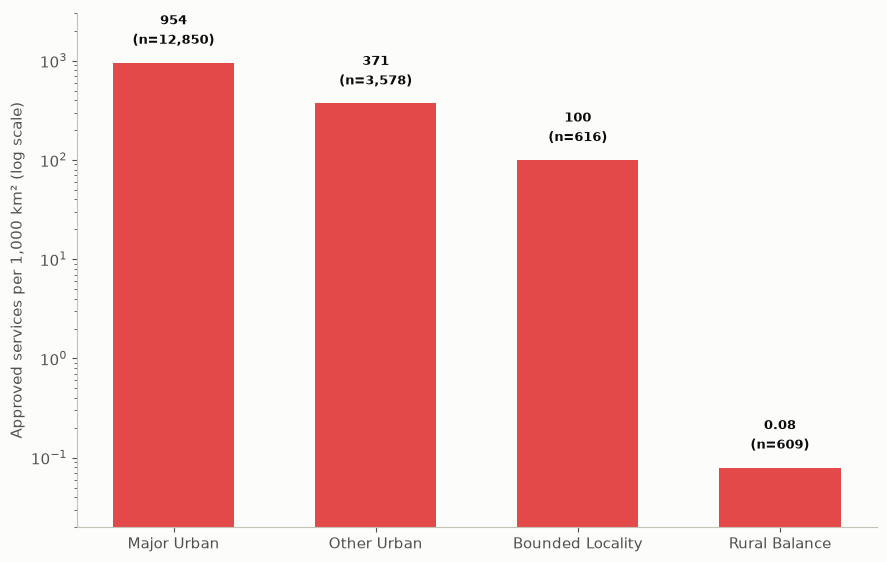

Density ratio (Major Urban : Rural Balance) = 12,003x


In [15]:

counts6 = df["SOS_Category"].value_counts()
density6 = (counts6 / sos_area_by_cat.reindex(counts6.index)) * 1000
density6 = density6.reindex(SOS_ORDER)

fig, ax = plt.subplots(figsize=(9, 5.8))
bars = ax.bar(SOS_ORDER, density6.values, color=CAT["red"], width=0.6)
ax.set_yscale("log")
ax.set_ylim(0.02, 3000)  # fixed range so every bar/label sits inside the axes
for bar, cat in zip(bars, SOS_ORDER):
    v = density6[cat]
    label = f"{v:,.0f}" if v >= 1 else f"{v:.2f}"
    ax.text(bar.get_x() + bar.get_width() / 2, v * 1.35, f"{label}\n(n={counts6[cat]:,})",
            ha="center", va="bottom", fontsize=9, fontweight="bold", linespacing=1.6)
ax.set_ylabel("Approved services per 1,000 km² (log scale)")
ratio6 = density6["Major Urban"] / density6["Rural Balance"]
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(BASELINE); ax.spines["bottom"].set_color(BASELINE)
fig.tight_layout()
fig.savefig(FIG_DIR / "06_geographic_distribution.png", dpi=200)
plt.show()

summary["density_major_urban_per_1000km2"] = round(float(density6["Major Urban"]), 1)
summary["density_rural_balance_per_1000km2"] = round(float(density6["Rural Balance"]), 3)
summary["density_ratio_urban_to_rural"] = round(float(ratio6), 0)
print(f"Density ratio (Major Urban : Rural Balance) = {ratio6:,.0f}x")


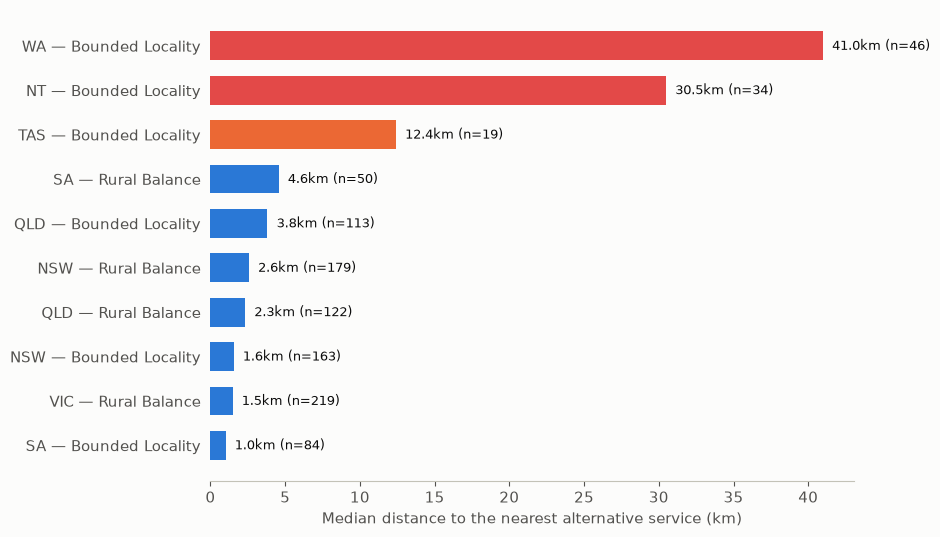

Most underserved: WA / Bounded Locality — median 41.0km to the nearest alternative service


In [16]:

pts7 = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs="EPSG:4326").to_crs("EPSG:3577")
coords7 = np.vstack([pts7.geometry.x, pts7.geometry.y]).T
dist7, _ = cKDTree(coords7).query(coords7, k=2)  # k=1 is the point itself
df["nearest_service_km"] = dist7[:, 1] / 1000

d7 = df[df["State"].notna() & df["SOS_Category"].notna()]
cell7 = d7.groupby(["State", "SOS_Category"]).agg(
    median_km=("nearest_service_km", "median"), n=("nearest_service_km", "size")
).reset_index()
cell7 = cell7[cell7["n"] >= MIN_CELL_N].sort_values("median_km", ascending=False).head(10)
cell7["label"] = cell7["State"] + " — " + cell7["SOS_Category"]

fig, ax = plt.subplots(figsize=(9.5, 5.5))
colors7 = [CAT["red"] if v > 20 else (CAT["orange"] if v > 5 else CAT["blue"]) for v in cell7["median_km"]]
bars = ax.barh(cell7["label"], cell7["median_km"], color=colors7, height=0.65)
ax.invert_yaxis()
for bar, km, n in zip(bars, cell7["median_km"], cell7["n"]):
    ax.text(bar.get_width() + max(cell7["median_km"]) * 0.015, bar.get_y() + bar.get_height() / 2,
            f"{km:.1f}km (n={n:,})", va="center", fontsize=9)
ax.set_xlabel("Median distance to the nearest alternative service (km)")
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "07_underserved_regions.png", dpi=200)
plt.show()

top7 = cell7.iloc[0]
summary["most_underserved_state_sos"] = f"{top7['State']} / {top7['SOS_Category']}"
summary["most_underserved_median_km"] = round(float(top7["median_km"]), 1)
summary["n_regions_over_20km_to_next_service"] = int((cell7["median_km"] > 20).sum())
print(f"Most underserved: {summary['most_underserved_state_sos']} — median {summary['most_underserved_median_km']}km to the nearest alternative service")


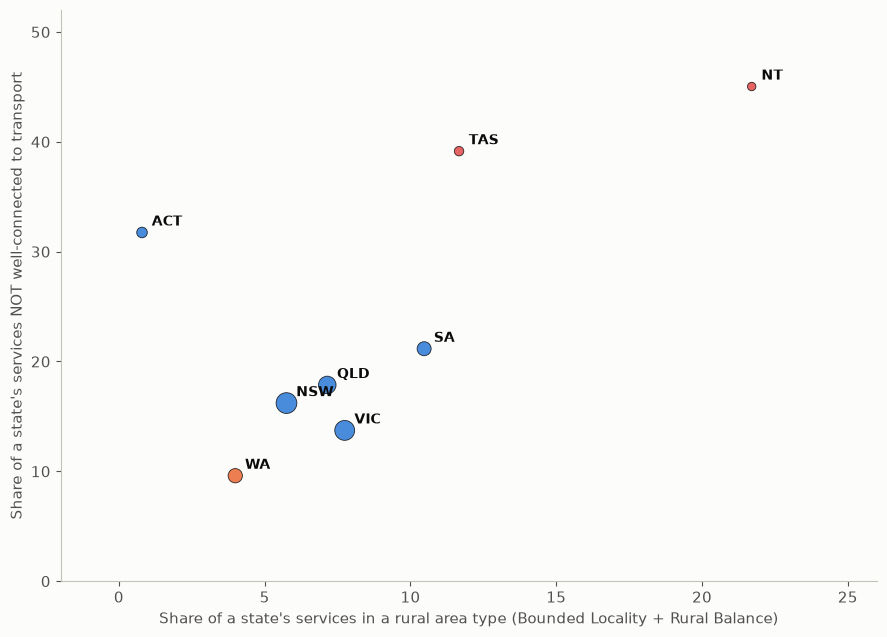

In [17]:

d8b = df[~df["train_dist_outlier"] & ~df["bus_dist_outlier"]].copy()
d8b["WellConnected"] = (d8b["DistanceToTrainStation_km"] <= TRAIN_CONNECTED_KM) | (d8b["DistanceToBusStation_km"] <= BUS_CONNECTED_KM)
d8b = d8b[d8b["State"].notna()]
poorly_connected8b = d8b.groupby("State")["WellConnected"].apply(lambda s: (~s).mean() * 100)
rural_share8b = df[df["State"].notna()].groupby("State")["SOS_Category"].apply(
    lambda s: s.isin(["Bounded Locality", "Rural Balance"]).mean() * 100
)
counts8b = d8b["State"].value_counts()
states8b = list(poorly_connected8b.index)
rural_share8b = rural_share8b.reindex(states8b)

rho8b, pval8b = stats.spearmanr(rural_share8b, poorly_connected8b)

fig, ax = plt.subplots(figsize=(9, 6.5))
sizes8b = (counts8b.reindex(states8b) ** 0.5) * 3
colors8b = [CAT["red"] if s in ("NT", "TAS") else (CAT["orange"] if s == "WA" else CAT["blue"]) for s in states8b]
ax.scatter(rural_share8b, poorly_connected8b, s=sizes8b, color=colors8b, alpha=0.85,
           edgecolors=INK_PRIMARY, linewidths=0.6, zorder=3)
for s in states8b:
    ax.annotate(s, (rural_share8b[s], poorly_connected8b[s]), xytext=(7, 5), textcoords="offset points",
                fontsize=10, fontweight="bold", color=INK_PRIMARY)
ax.set_xlim(-2, 26)
ax.set_ylim(0, 52)
ax.set_xlabel("Share of a state's services in a rural area type (Bounded Locality + Rural Balance)")
ax.set_ylabel("Share of a state's services NOT well-connected to transport")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(BASELINE); ax.spines["bottom"].set_color(BASELINE)
fig.tight_layout()
fig.savefig(FIG_DIR / "08_state_connectivity_vs_rurality.png", dpi=200)
plt.show()

summary["state_rural_share_pct"] = {s: round(float(rural_share8b[s]), 1) for s in states8b}
summary["state_poorly_connected_pct"] = {s: round(float(poorly_connected8b[s]), 1) for s in states8b}
summary["state_rurality_connectivity_spearman_rho"] = round(float(rho8b), 4)
summary["state_rurality_connectivity_spearman_p"] = float(pval8b)


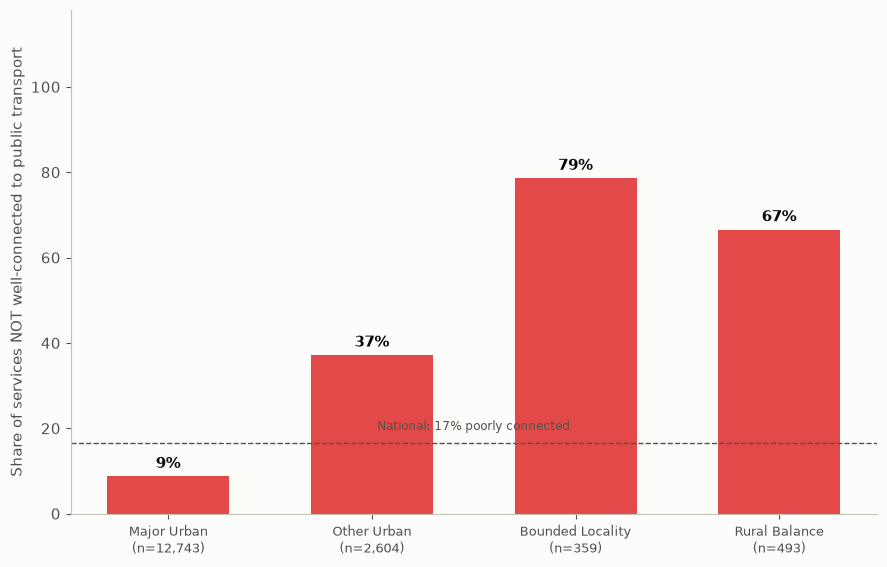

National: 16.6% poorly connected. By area: {'Major Urban': np.float64(8.7), 'Other Urban': np.float64(37.1), 'Bounded Locality': np.float64(78.6), 'Rural Balance': np.float64(66.5)}


In [18]:

d8 = df[~df["train_dist_outlier"] & ~df["bus_dist_outlier"]].copy()
d8["WellConnected"] = (d8["DistanceToTrainStation_km"] <= TRAIN_CONNECTED_KM) | (d8["DistanceToBusStation_km"] <= BUS_CONNECTED_KM)
d8 = d8[d8["SOS_Category"].notna()]
poorly_connected8 = d8.groupby("SOS_Category")["WellConnected"].apply(lambda s: (~s).mean() * 100).reindex(SOS_ORDER)
counts8 = d8["SOS_Category"].value_counts().reindex(SOS_ORDER)
national_poor8 = (~d8["WellConnected"]).mean() * 100

fig, ax = plt.subplots(figsize=(9, 5.8))
bars = ax.bar(SOS_ORDER, poorly_connected8.values, color=CAT["red"], width=0.6)
for bar, cat in zip(bars, SOS_ORDER):
    v = poorly_connected8[cat]
    ax.text(bar.get_x() + bar.get_width() / 2, v + 2, f"{v:.0f}%", ha="center", fontsize=11, fontweight="bold")
ax.set_xticks(range(len(SOS_ORDER)))
ax.set_xticklabels([f"{cat}\n(n={counts8[cat]:,})" for cat in SOS_ORDER], fontsize=9.5)
ax.axhline(national_poor8, color=INK_SECONDARY, linestyle="--", linewidth=1)
ax.text(1.5, national_poor8 + 3, f"National: {national_poor8:.0f}% poorly connected",
        ha="center", fontsize=8.5, color=INK_SECONDARY)
ax.set_ylim(0, 118)
ax.set_ylabel("Share of services NOT well-connected to public transport")
gap8 = poorly_connected8["Bounded Locality"] - poorly_connected8["Major Urban"]
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(BASELINE); ax.spines["bottom"].set_color(BASELINE)
fig.tight_layout()
fig.savefig(FIG_DIR / "09_transport_connectivity.png", dpi=200)
plt.show()

summary["national_poorly_connected_pct"] = round(float(national_poor8), 1)
for cat in SOS_ORDER:
    summary[f"poorly_connected_{cat.lower().replace(' ', '_')}_pct"] = round(float(poorly_connected8[cat]), 1)
print(f"National: {national_poor8:.1f}% poorly connected. By area: {dict(poorly_connected8.round(1))}")


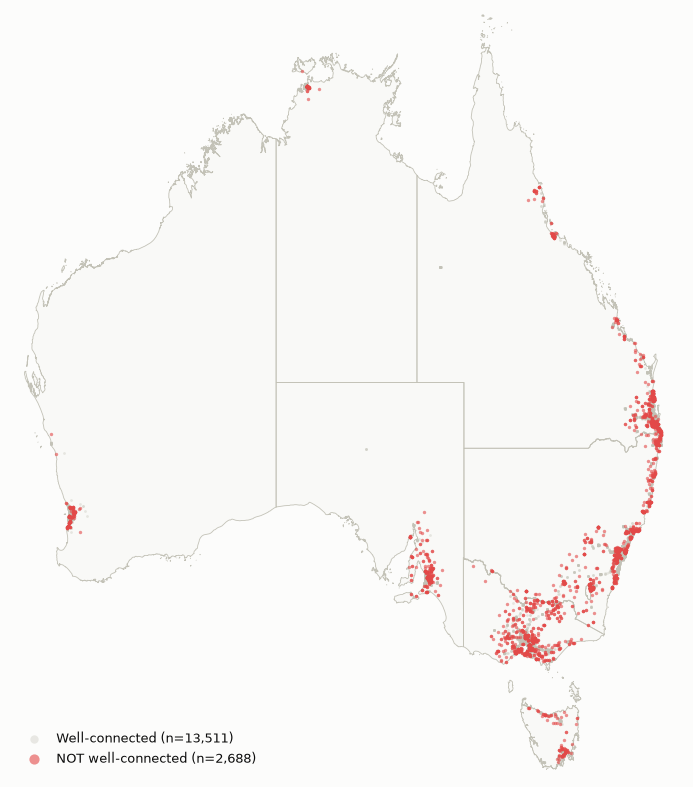

In [19]:

d9 = df[~df["train_dist_outlier"] & ~df["bus_dist_outlier"]].copy()
d9["WellConnected"] = (d9["DistanceToTrainStation_km"] <= TRAIN_CONNECTED_KM) | (d9["DistanceToBusStation_km"] <= BUS_CONNECTED_KM)
d9 = d9[d9["lon"].notna() & d9["lat"].notna() & ~d9["geocode_suspect"]]
states = gpd.read_file(AU_STATES_GEOJSON)

fig, ax = plt.subplots(figsize=(9, 8))
states.boundary.plot(ax=ax, color=BASELINE, linewidth=0.6)
states.plot(ax=ax, color="#f9f9f7", edgecolor="none", zorder=0)

connected9 = d9[d9["WellConnected"]]
poor9 = d9[~d9["WellConnected"]]
ax.scatter(connected9["lon"], connected9["lat"], s=4, alpha=0.35, linewidths=0,
           color=BASELINE, label=f"Well-connected (n={len(connected9):,})", zorder=2)
ax.scatter(poor9["lon"], poor9["lat"], s=6, alpha=0.6, linewidths=0,
           color=CAT["red"], label=f"NOT well-connected (n={len(poor9):,})", zorder=3)

ax.set_xlim(112, 155); ax.set_ylim(-44, -9); ax.set_aspect(1.4)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc="lower left", frameon=False, fontsize=9, markerscale=3)
fig.tight_layout()
fig.savefig(FIG_DIR / "10_spatial_connectivity.png", dpi=200)
plt.show()

summary["n_poorly_connected"] = int(len(poor9))
summary["n_well_connected"] = int(len(connected9))


In [20]:

DAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

has_annual = df["Annual Monday Start Time"].notna()
has_term = df["School Terms Only Session 1 Monday Start Time"].notna()
df["OperatingPattern"] = "Neither / other pattern"
df.loc[~has_annual & has_term, "OperatingPattern"] = "Term-time only"
df.loc[has_annual, "OperatingPattern"] = "Year-round"


def to_hours(series):
    return pd.to_timedelta(series.astype(str), errors="coerce").dt.total_seconds() / 3600


total_hours = pd.Series(0.0, index=df.index)
for day in DAYS:
    start = to_hours(df[f"Annual {day} Start Time"])
    end = to_hours(df[f"Annual {day} End Time"])
    total_hours = total_hours.add((end - start).clip(lower=0).fillna(0))
df["WeeklyHours"] = np.where(has_annual, total_hours, np.nan)

# Family Day Care schemes record round-the-clock availability across their
# whole educator network (median ~168h/week = "always open"), which isn't
# a comparable "opening hours" figure to a single centre's - excluded from
# the hours analysis, kept for the capacity/type charts.
df.loc[df["PrimaryServiceType"] == "Family Day Care", "WeeklyHours"] = np.nan

print(df["OperatingPattern"].value_counts())
print()
print(df["WeeklyHours"].describe())


OperatingPattern
Year-round                 10633
Term-time only              6093
Neither / other pattern      927
Name: count, dtype: int64

count    10267.000000
mean        53.731492
std          9.976385
min          0.000000
25%         52.500000
50%         55.000000
75%         60.000000
max        167.883333
Name: WeeklyHours, dtype: float64


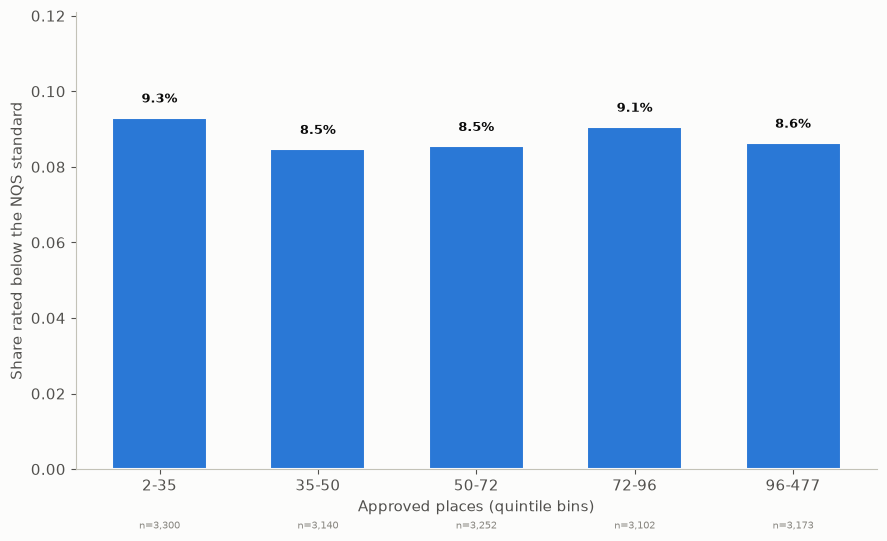

In [21]:

# Family Day Care excluded: capacity is recorded per individually-registered
# educator across a scheme, not as a single site limit, so NumberOfApprovedPlaces
# is populated for only 2 of 417 FDC services - not enough for a meaningful median.
d10 = df[~df["PrimaryServiceType"].isin(["Other", "Family Day Care"])].copy()
d10 = d10.dropna(subset=["NumberOfApprovedPlaces"])
d10 = d10[d10["OverallRating"].notna()]
d10["OverallRating"] = d10["OverallRating"].astype(str)
d10 = d10[d10["OverallRating"] != NOT_YET_ASSESSED]
d10["BelowStandard"] = d10["OverallRating"].isin(["Working Towards NQS", "Significant Improvement Required"]).astype(int)
sos_places = df.groupby("SOS_Category")["NumberOfApprovedPlaces"].median()

# Quantile bins (not fixed cutoffs) so each bin has enough services for a
# reliable rate and the labels show the real capacity range.
d10["cap_bin"], edges10 = pd.qcut(d10["NumberOfApprovedPlaces"], q=5, retbins=True, duplicates="drop")
labels10 = [f"{int(edges10[i])}-{int(edges10[i + 1])}" for i in range(len(edges10) - 1)]
d10["cap_bin"] = pd.qcut(d10["NumberOfApprovedPlaces"], q=5, labels=labels10, duplicates="drop")
props10 = d10.groupby("cap_bin", observed=True)["BelowStandard"].mean()
counts10 = d10["cap_bin"].value_counts().reindex(labels10)

rho10, pval10 = stats.spearmanr(d10["NumberOfApprovedPlaces"], d10["BelowStandard"])

ymax10 = max(props10.max() * 1.3, 0.05)
fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(labels10, props10.reindex(labels10).values, color=CAT["blue"], width=0.6, edgecolor=SURFACE, linewidth=1.5)
for bar, lbl in zip(bars, labels10):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004, f"{bar.get_height():.1%}",
            ha="center", fontsize=9, color=INK_PRIMARY, fontweight="bold")
    ax.text(bar.get_x() + bar.get_width() / 2, -0.13 * ymax10, f"n={counts10[lbl]:,}",
            ha="center", fontsize=7.5, color=INK_MUTED)
ax.set_ylim(0, ymax10)
ax.set_xlabel("Approved places (quintile bins)")
ax.set_ylabel("Share rated below the NQS standard")
sos_line10 = "  |  ".join(f"{cat}: {sos_places[cat]:.0f}" for cat in SOS_ORDER)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(BASELINE); ax.spines["bottom"].set_color(BASELINE)
fig.tight_layout()
fig.savefig(FIG_DIR / "11_capacity_by_type.png", dpi=200)
plt.show()

for cat in SOS_ORDER:
    summary[f"median_places_{cat.lower().replace(' ', '_')}"] = round(float(sos_places[cat]), 1)
summary["capacity_noncompliance_spearman_rho"] = round(float(rho10), 4)
summary["capacity_noncompliance_spearman_p"] = float(pval10)
summary["noncompliance_pct_smallest_capacity_bin"] = round(float(props10.iloc[0]) * 100, 1)
summary["noncompliance_pct_largest_capacity_bin"] = round(float(props10.iloc[-1]) * 100, 1)


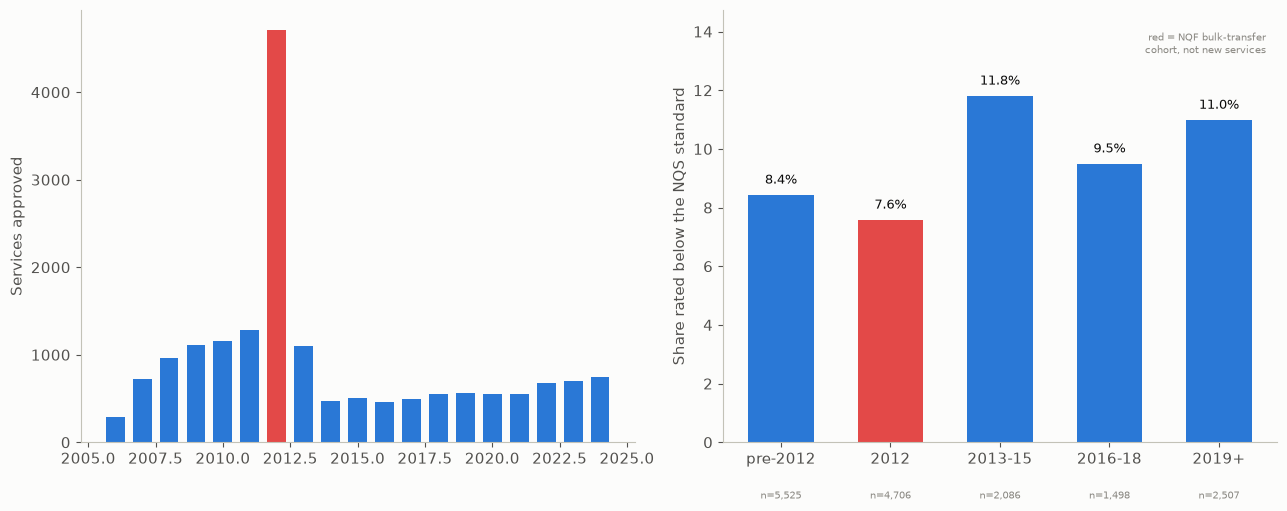

In [22]:

d12 = df[df["ApprovalYear"].between(2006, 2024)]
by_year = d12.groupby("ApprovalYear").size()

rated12 = d12[d12["OverallRating"].notna()].copy()
rated12["OverallRating"] = rated12["OverallRating"].astype(str)
rated12 = rated12[rated12["OverallRating"] != NOT_YET_ASSESSED]
bins12 = [2005, 2012, 2013, 2016, 2019, 2025]
labels12 = ["pre-2012", "2012", "2013-15", "2016-18", "2019+"]
rated12["cohort"] = pd.cut(rated12["ApprovalYear"], bins=bins12, labels=labels12, right=False)
cohort_noncompliance = rated12.groupby("cohort", observed=True)["OverallRating"].apply(lambda s: s.isin(["Working Towards NQS", "Significant Improvement Required"]).mean())
cohort_counts = rated12["cohort"].value_counts().reindex(labels12)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2))

colors12 = [CAT["red"] if y == 2012 else CAT["blue"] for y in by_year.index]
ax1.bar(by_year.index, by_year.values, color=colors12, width=0.7)
ax1.set_ylabel("Services approved")
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)
ax1.spines["left"].set_color(BASELINE); ax1.spines["bottom"].set_color(BASELINE)

bar_colors12 = [CAT["red"] if lbl == "2012" else CAT["blue"] for lbl in labels12]
ymax12 = max(cohort_noncompliance.max() * 100 * 1.25, 5)
bars2 = ax2.bar(labels12, (cohort_noncompliance.reindex(labels12) * 100).values, color=bar_colors12, width=0.6)
for bar, lbl in zip(bars2, labels12):
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, h + 0.4, f"{h:.1f}%", ha="center", fontsize=9)
    ax2.text(bar.get_x() + bar.get_width() / 2, -0.13 * ymax12, f"n={cohort_counts[lbl]:,}", ha="center", fontsize=7.5, color=INK_MUTED)
ax2.set_ylim(0, ymax12)
ax2.set_ylabel("Share rated below the NQS standard")
ax2.text(0.98, 0.95, "red = NQF bulk-transfer\ncohort, not new services", transform=ax2.transAxes, ha="right", va="top", fontsize=7.5, color=INK_MUTED)
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)
ax2.spines["left"].set_color(BASELINE); ax2.spines["bottom"].set_color(BASELINE)

fig.tight_layout()
fig.savefig(FIG_DIR / "12_approval_trend.png", dpi=200)
plt.show()

summary["approvals_2012_nqf_spike"] = int(by_year.loc[2012])
summary["approvals_2014"] = int(by_year.loc[2014])
summary["approvals_2024"] = int(by_year.loc[2024])
summary["noncompliance_pct_pre2012_cohort"] = round(float(cohort_noncompliance["pre-2012"]) * 100, 1)
summary["noncompliance_pct_2019plus_cohort"] = round(float(cohort_noncompliance["2019+"]) * 100, 1)


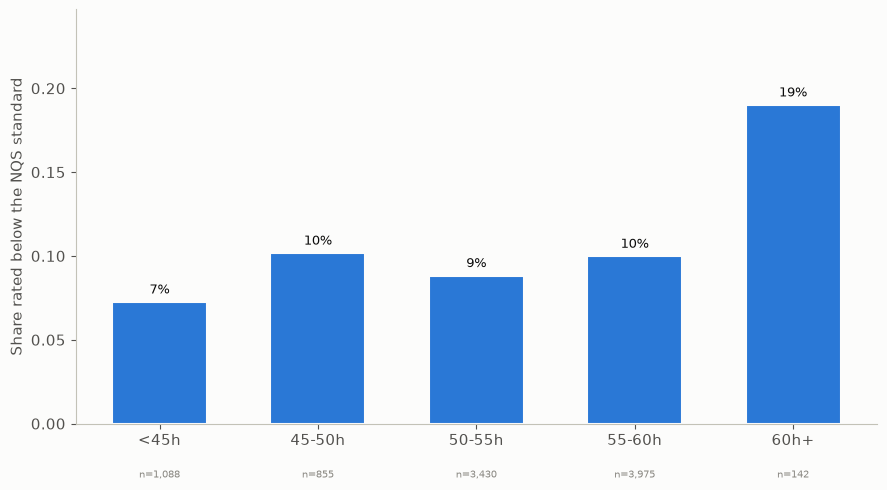

In [23]:

d13 = df[df["OverallRating"].notna() & df["WeeklyHours"].notna()].copy()
d13["OverallRating"] = d13["OverallRating"].astype(str)
d13 = d13[d13["OverallRating"] != NOT_YET_ASSESSED]
d13 = d13[d13["WeeklyHours"].between(1, 100)]
d13["BelowStandard"] = d13["OverallRating"].isin(["Working Towards NQS", "Significant Improvement Required"]).astype(int)

bins13 = [0, 45, 50, 55, 60, 100]
labels13 = ["<45h", "45-50h", "50-55h", "55-60h", "60h+"]
d13["hours_bin"] = pd.cut(d13["WeeklyHours"], bins=bins13, labels=labels13)
props13 = d13.groupby("hours_bin", observed=True)["BelowStandard"].mean()
counts13 = d13["hours_bin"].value_counts().reindex(labels13)

rho_hours, p_hours = stats.spearmanr(d13["WeeklyHours"], d13["BelowStandard"])

cap13 = df.dropna(subset=["NumberOfApprovedPlaces"])
cap13 = cap13[~cap13["train_dist_outlier"]]
rho_cap, p_cap = stats.spearmanr(cap13["DistanceToTrainStation_km"], cap13["NumberOfApprovedPlaces"])

hrs13 = df.dropna(subset=["WeeklyHours"])
hrs13 = hrs13[~hrs13["train_dist_outlier"] & hrs13["WeeklyHours"].between(1, 100)]
rho_transport_hours, p_transport_hours = stats.spearmanr(hrs13["DistanceToTrainStation_km"], hrs13["WeeklyHours"])

ymax13 = max(props13.max() * 1.3, 0.05)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels13, props13.reindex(labels13).values, color=CAT["blue"], width=0.6, edgecolor=SURFACE, linewidth=1.5)
for bar, lbl in zip(bars, labels13):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{bar.get_height():.0%}", ha="center", fontsize=9, color=INK_PRIMARY)
    ax.text(bar.get_x() + bar.get_width() / 2, -0.13 * ymax13, f"n={counts13[lbl]:,}", ha="center", fontsize=7.5, color=INK_MUTED)
ax.set_ylim(0, ymax13)
ax.set_ylabel("Share rated below the NQS standard")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(BASELINE); ax.spines["bottom"].set_color(BASELINE)
fig.tight_layout()
fig.savefig(FIG_DIR / "13_hours_vs_quality.png", dpi=200)
plt.show()

summary["hours_noncompliance_spearman_rho"] = round(float(rho_hours), 4)
summary["hours_noncompliance_spearman_p"] = float(p_hours)
summary["noncompliance_pct_shortest_hours_bin"] = round(float(props13.iloc[0]) * 100, 1)
summary["noncompliance_pct_longest_hours_bin"] = round(float(props13.iloc[-1]) * 100, 1)
summary["transport_capacity_spearman_rho"] = round(float(rho_cap), 4)
summary["transport_hours_spearman_rho"] = round(float(rho_transport_hours), 4)
summary["transport_hours_spearman_p"] = float(p_transport_hours)


In [24]:

Path("outputs").mkdir(exist_ok=True)
Path("outputs/summary_stats.json").write_text(json.dumps(summary, indent=2, default=str))
summary


{'n_services_total': 17653,
 'best_state': 'VIC',
 'worst_state': 'NT',
 'best_state_noncompliance_pct': 4.4,
 'worst_state_noncompliance_pct': 21.9,
 'service_type_counts': {'Long Day Care': 8636,
  'Outside School Hours Care': 4446,
  'Preschool (standalone)': 2232,
  'Preschool (school-based)': 655,
  'Family Day Care': 355},
 'weakest_quality_area_nationally': 'QA1 Educational program',
 'strongest_quality_area_nationally': 'QA6 Collaborative partnerships',
 'n_mapped': 17653,
 'n_excluded_suspect_geocode': 0,
 'transport_belowstandard_spearman_rho': 0.0259,
 'transport_belowstandard_spearman_p': 0.0010535622964976603,
 'belowstandard_pct_closest_bin': 7.6,
 'belowstandard_pct_farthest_bin': 10.3,
 'n_excluded_remote_outliers': 296,
 'urban_rural_counts': {'Urban': 16428, 'Rural': 1225},
 'sos_category_counts': {'Major Urban': 12850,
  'Other Urban': 3578,
  'Bounded Locality': 616,
  'Rural Balance': 609},
 'density_major_urban_per_1000km2': 954.4,
 'density_rural_balance_per_1000